In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
import pandas as pd
import pyarrow.parquet as pq

path = "../datasets/NF-ToN-IoT-v2.parquet"

# cek label (tetap cepat)
df = pd.read_parquet(path, columns=["Label"])
print(df["Label"].value_counts(normalize=True))

frac = 0.001

parquet_file = pq.ParquetFile(path)

samples = []

for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(i).to_pandas()

    sampled_chunk = (
        chunk
        .groupby("Label", group_keys=False)
        .sample(frac=frac, random_state=42)
    )

    samples.append(sampled_chunk)

df_sample = pd.concat(samples, ignore_index=True)

print("Sample shape:", df_sample.shape)
print(df_sample["Label"].value_counts(normalize=True))

df_sample.to_parquet("../datasets/NF-ToN-IoT-v2_sample.parquet", index=False)

Label
1    0.639947
0    0.360053
Name: proportion, dtype: float64
Sample shape: (16941, 45)
Label
1    0.640222
0    0.359778
Name: proportion, dtype: float64


In [3]:
df_sample.head()

,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,...,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,Label,Attack
0,192.168.1.32,40118,192.168.1.49,1310,6,0.0,44,1,0,0,...,1024,0,0,0,0,0,0,0,0,Benign
1,192.168.1.31,54319,192.168.1.49,9618,6,0.0,44,1,0,0,...,1024,0,0,0,0,0,0,0,0,Benign
2,192.168.1.31,62849,192.168.1.49,3517,6,0.0,44,1,40,1,...,1024,0,0,0,0,0,0,0,0,Benign
3,192.168.1.32,40143,192.168.1.49,1277,6,0.0,44,1,0,0,...,1024,0,0,0,0,0,0,0,0,Benign
4,192.168.1.31,35188,192.168.1.49,4003,6,0.0,44,1,40,1,...,1024,0,0,0,0,0,0,0,0,Benign


In [4]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16941 entries, 0 to 16940
Data columns (total 45 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   IPV4_SRC_ADDR                16941 non-null  object 
 1   L4_SRC_PORT                  16941 non-null  int64  
 2   IPV4_DST_ADDR                16941 non-null  object 
 3   L4_DST_PORT                  16941 non-null  int64  
 4   PROTOCOL                     16941 non-null  int64  
 5   L7_PROTO                     16941 non-null  float64
 6   IN_BYTES                     16941 non-null  int64  
 7   IN_PKTS                      16941 non-null  int64  
 8   OUT_BYTES                    16941 non-null  int64  
 9   OUT_PKTS                     16941 non-null  int64  
 10  TCP_FLAGS                    16941 non-null  int64  
 11  CLIENT_TCP_FLAGS             16941 non-null  int64  
 12  SERVER_TCP_FLAGS             16941 non-null  int64  
 13  FLOW_DURATION_MI

In [5]:
df_sample.describe().T

,count,mean,std,min,25%,50%,75%,max
L4_SRC_PORT,16941.0,4.344750e+04,1.509553e+04,0.0,37420.0,45868.0,54327.0,6.552600e+04
L4_DST_PORT,16941.0,9.269542e+03,1.688713e+04,0.0,80.0,443.0,8031.0,6.553400e+04
PROTOCOL,16941.0,7.616374e+00,3.936148e+00,1.0,6.0,6.0,6.0,5.800000e+01
L7_PROTO,16941.0,1.369459e+01,3.184938e+01,0.0,0.0,0.0,7.0,2.440000e+02
IN_BYTES,16941.0,4.105718e+02,1.427882e+03,4.0,44.0,52.0,276.0,1.119600e+05
IN_PKTS,16941.0,4.156779e+00,2.749163e+01,1.0,1.0,1.0,4.0,2.799000e+03
OUT_BYTES,16941.0,5.404018e+02,1.717748e+03,0.0,0.0,40.0,180.0,6.503900e+04
OUT_PKTS,16941.0,2.329496e+00,5.414620e+00,0.0,0.0,1.0,3.0,1.160000e+02
TCP_FLAGS,16941.0,1.279299e+01,1.124624e+01,0.0,2.0,17.0,22.0,4.100000e+01
CLIENT_TCP_FLAGS,16941.0,9.485627e+00,1.086533e+01,0.0,2.0,2.0,18.0,4.100000e+01


In [6]:
df_sample["Label"].value_counts()

Label
1    10846
0     6095
Name: count, dtype: int64

In [7]:
df_sample["Attack"].value_counts()

Attack
Benign        6095
scanning      3799
xss           2472
ddos          2067
password      1085
dos            699
injection      697
backdoor        19
mitm             5
ransomware       3
Name: count, dtype: int64

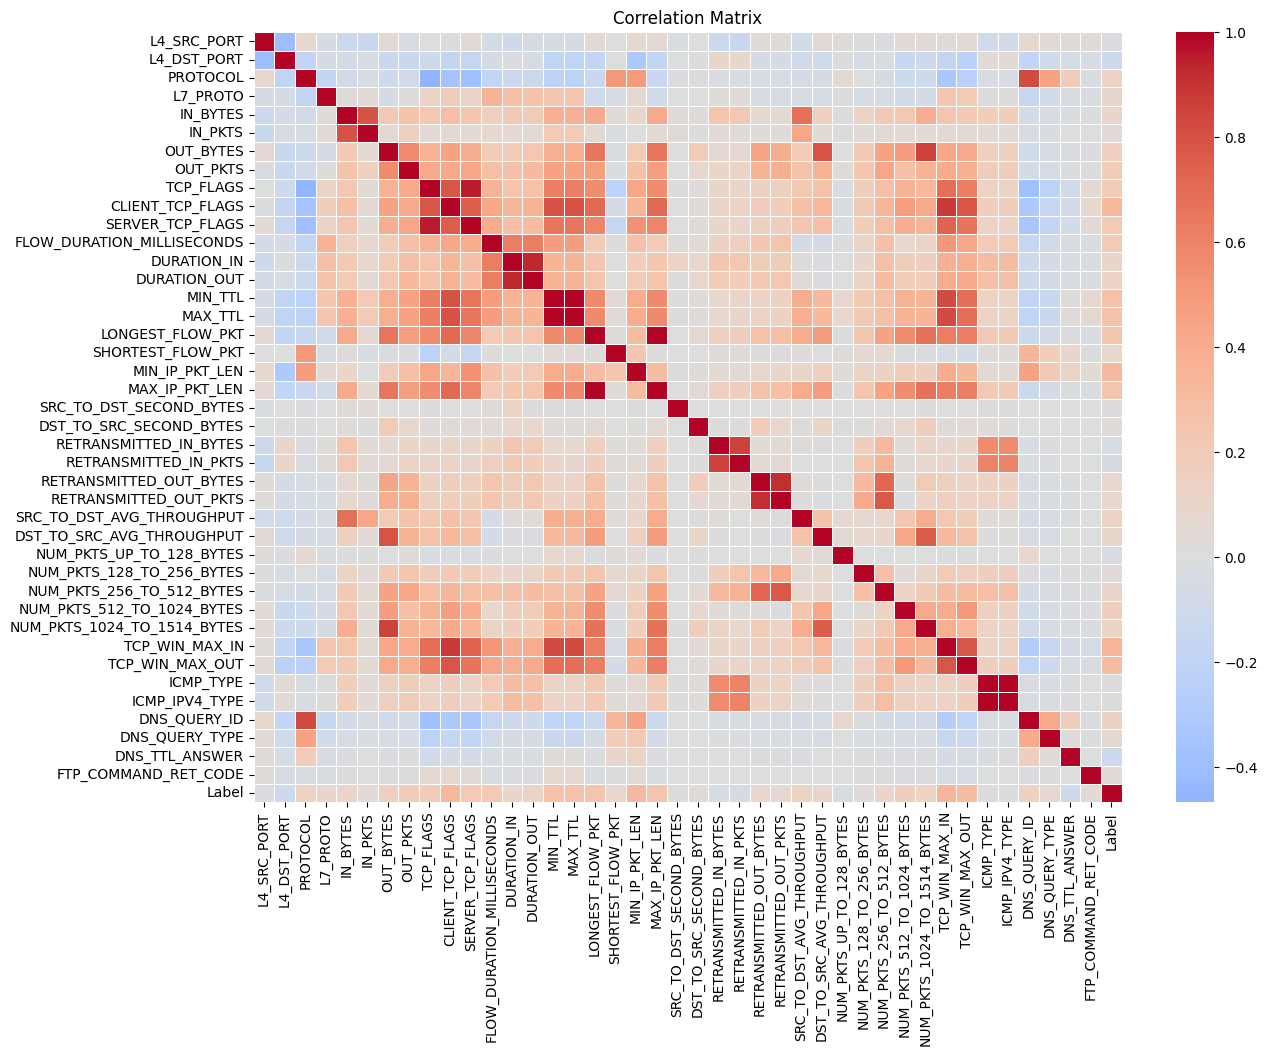

In [8]:
plt.figure(figsize=(14,10))
corr = df_sample.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

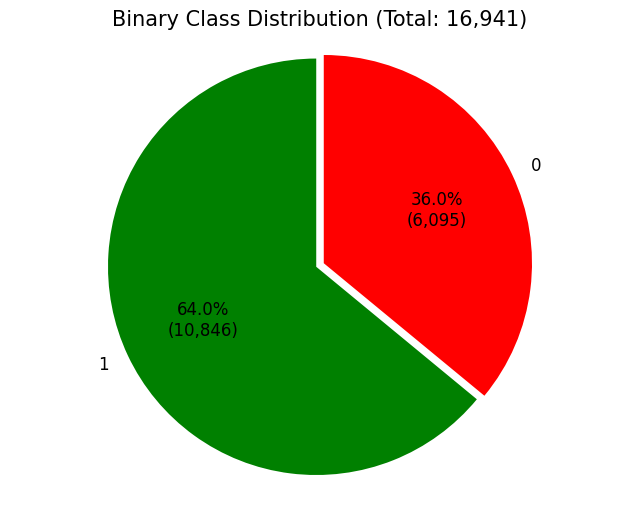

In [9]:
def autopct_format(values):
    def inner(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val:,})'
    return inner

# ambil data label
label_counts = df_sample["Label"].value_counts()

labels = label_counts.index.astype(str)
sizes = label_counts.values
colors = ["green", "red"]

plt.figure(figsize=(8, 6))

plt.pie(
    sizes,
    labels=labels,
    autopct=autopct_format(sizes),
    colors=colors,
    startangle=90,
    explode=[0.02] * len(labels),
    textprops={'fontsize': 12}
)

plt.title(f'Binary Class Distribution (Total: {label_counts.sum():,})', fontsize=15)

plt.axis('equal')
plt.show()

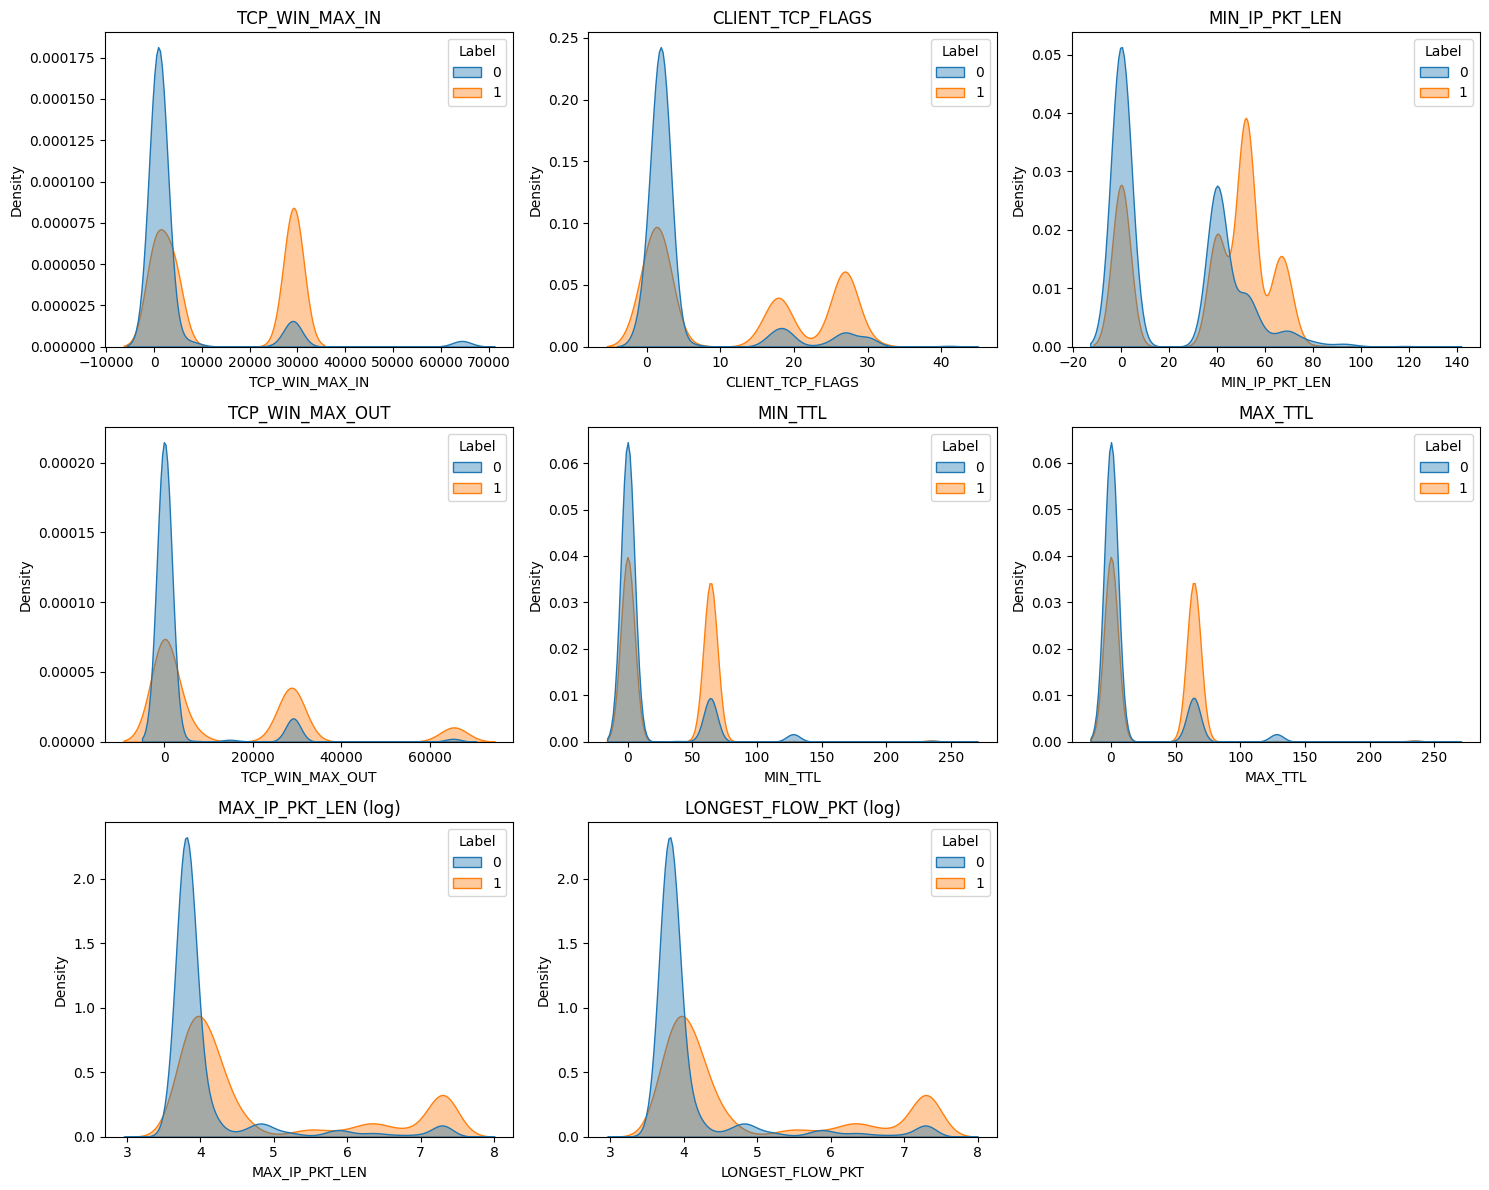

In [10]:
numeric_df = df_sample.select_dtypes(include=["int64", "float64"])

corr_with_label = (
    numeric_df
    .corr()["Label"]
    .abs()
    .sort_values(ascending=False)
)

top_features = corr_with_label.index[1:9]
n_cols = 3
n_rows = int(np.ceil(len(top_features) / n_cols))
plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(top_features):
    plt.subplot(n_rows, n_cols, i + 1)

    values = df_sample[col]

    if (values > 0).all():
        values = np.log1p(values)
        title = f"{col} (log)"
    else:
        title = col

    sns.kdeplot(
        x=values,
        hue=df_sample["Label"],
        common_norm=False,
        fill=True,
        alpha=0.4
    )

    plt.title(title)

plt.tight_layout()
plt.show()

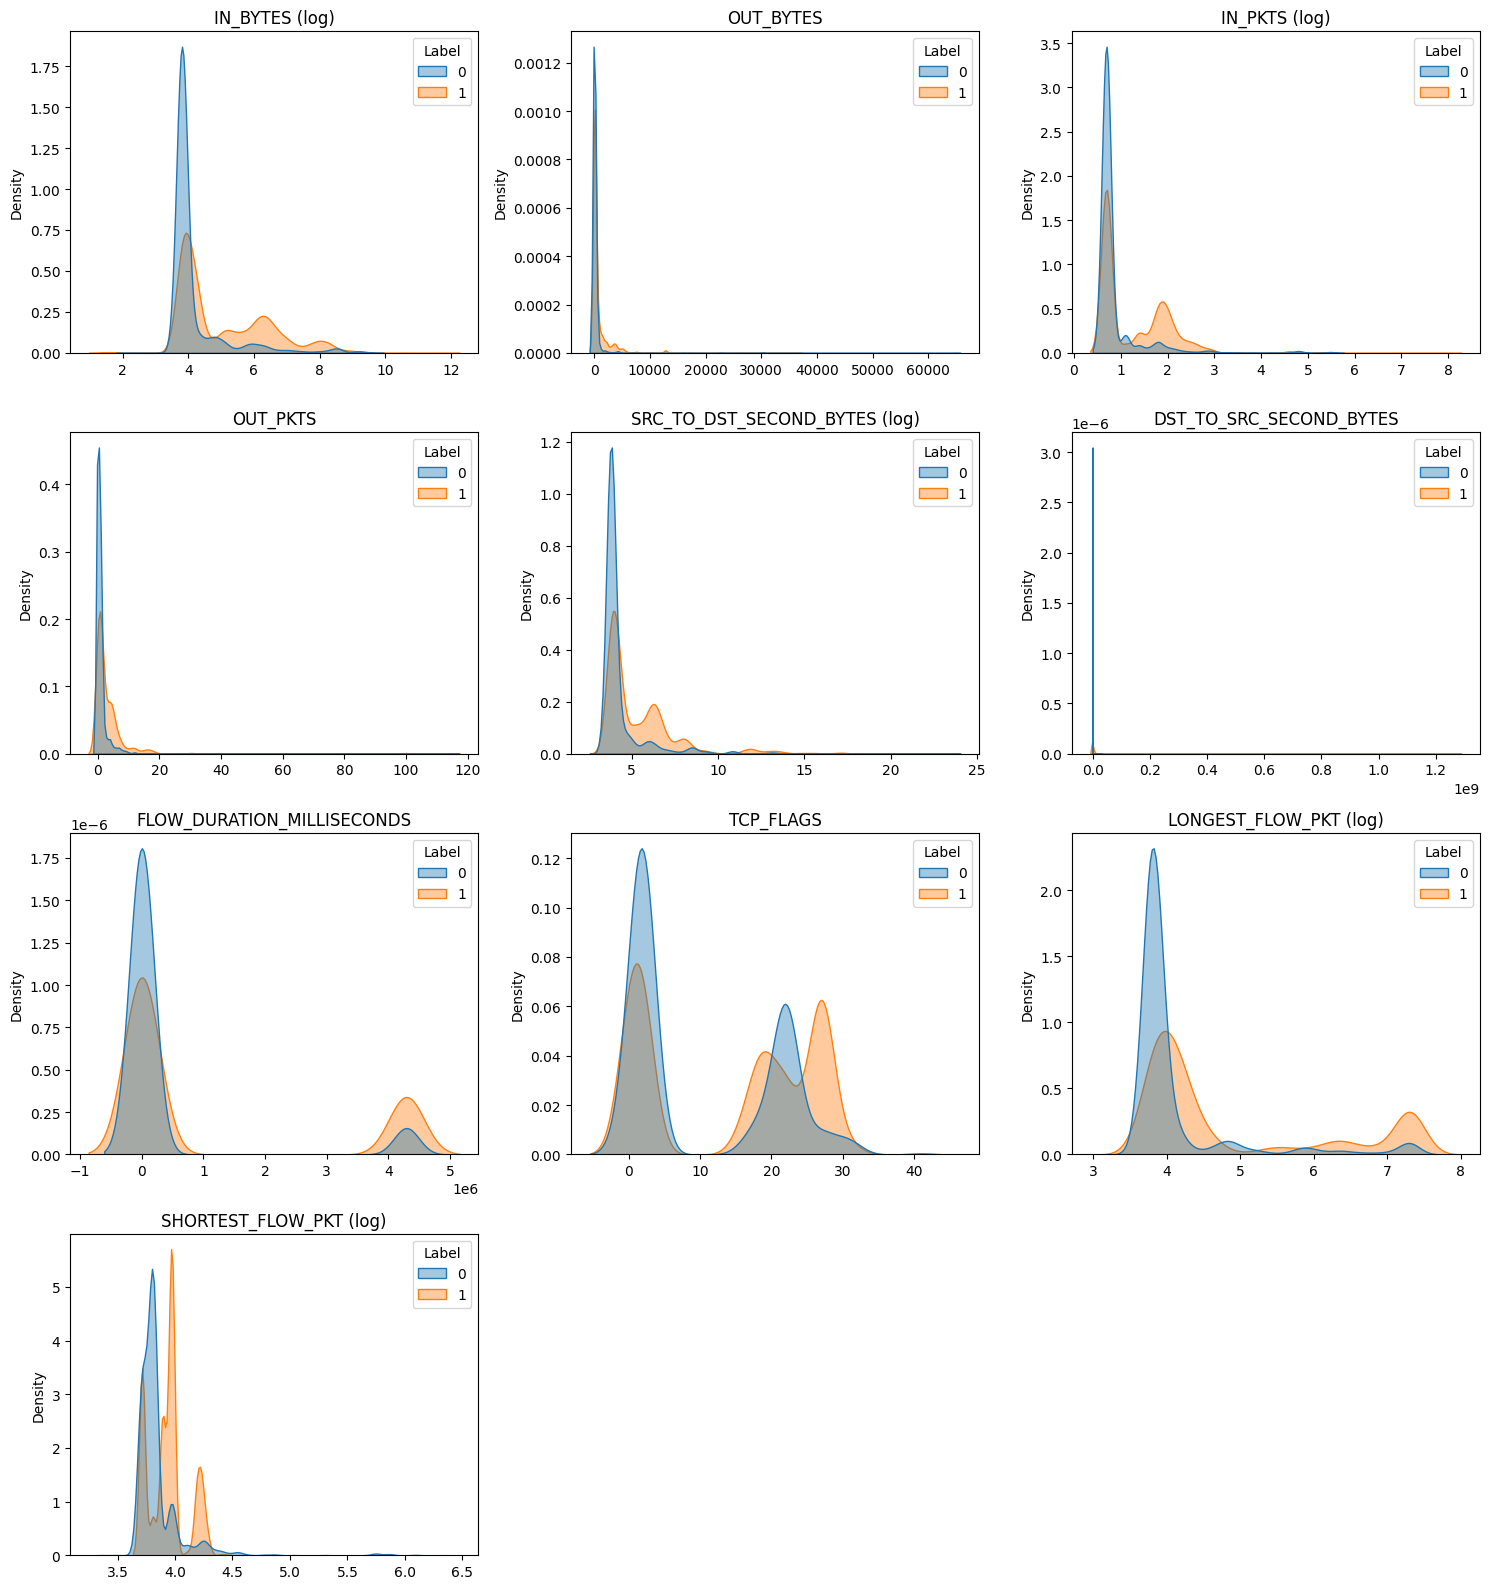

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Top 10 Features You Selected
# ==============================

top_features = [
    "IN_BYTES",
    "OUT_BYTES",
    "IN_PKTS",
    "OUT_PKTS",
    "SRC_TO_DST_SECOND_BYTES",
    "DST_TO_SRC_SECOND_BYTES",
    "FLOW_DURATION_MILLISECONDS",
    "TCP_FLAGS",
    "LONGEST_FLOW_PKT",
    "SHORTEST_FLOW_PKT"
]

# Keep only numeric columns
numeric_df = df_sample.select_dtypes(include=["int64", "float64"])

# Clean data
numeric_df.replace([np.inf, -np.inf], np.nan, inplace=True)
numeric_df.fillna(0, inplace=True)

# ==============================
# Plot Layout
# ==============================

n_cols = 3
n_rows = int(np.ceil(len(top_features) / n_cols))

plt.figure(figsize=(15, 4 * n_rows))

# ==============================
# Plot Loop
# ==============================

for i, col in enumerate(top_features):

    if col not in numeric_df.columns:
        continue

    plt.subplot(n_rows, n_cols, i + 1)

    values = numeric_df[col]

    # Log transform for skewed positive features
    if (values > 0).all():
        values = np.log1p(values)
        title = f"{col} (log)"
    else:
        title = col

    sns.kdeplot(
        x=values,
        hue=df_sample["Label"],
        common_norm=False,
        fill=True,
        alpha=0.4
    )

    plt.title(title)
    plt.xlabel("")
    plt.ylabel("Density")

plt.tight_layout()
plt.show()


In [12]:
from sklearn.feature_selection import f_classif

X = numeric_df[top_features]
y = df_sample["Label"]

f_scores, p_values = f_classif(X, y)

anova_df = pd.DataFrame({
    "Feature": top_features,
    "F_score": f_scores,
    "p_value": p_values
})

anova_df = anova_df.sort_values(
    by="F_score",
    ascending=False
)

print(anova_df)


                      Feature      F_score        p_value
8            LONGEST_FLOW_PKT  1070.398396  1.033934e-227
6  FLOW_DURATION_MILLISECONDS   739.735048  1.791491e-159
3                    OUT_PKTS   632.821666  3.960478e-137
7                   TCP_FLAGS   615.722336  1.529537e-133
1                   OUT_BYTES   437.644588   5.748183e-96
0                    IN_BYTES   163.963149   2.296736e-37
9           SHORTEST_FLOW_PKT   130.048535   5.145609e-30
2                     IN_PKTS    18.680490   1.554374e-05
5     DST_TO_SRC_SECOND_BYTES     4.581863   3.232629e-02
4     SRC_TO_DST_SECOND_BYTES     2.434678   1.186970e-01


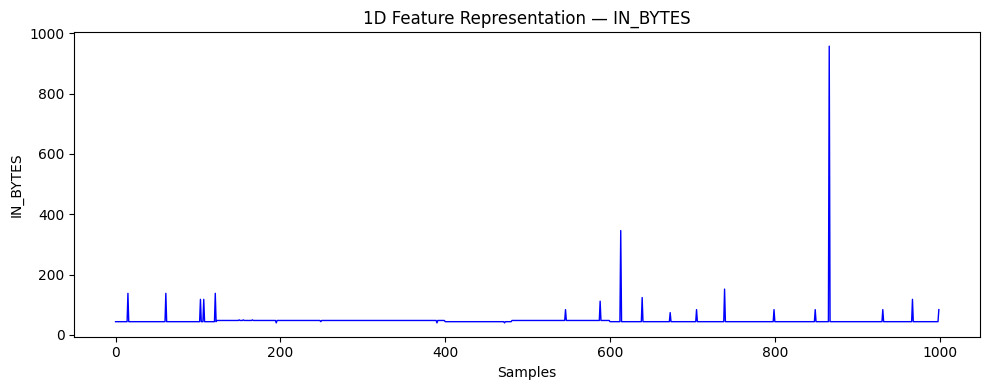

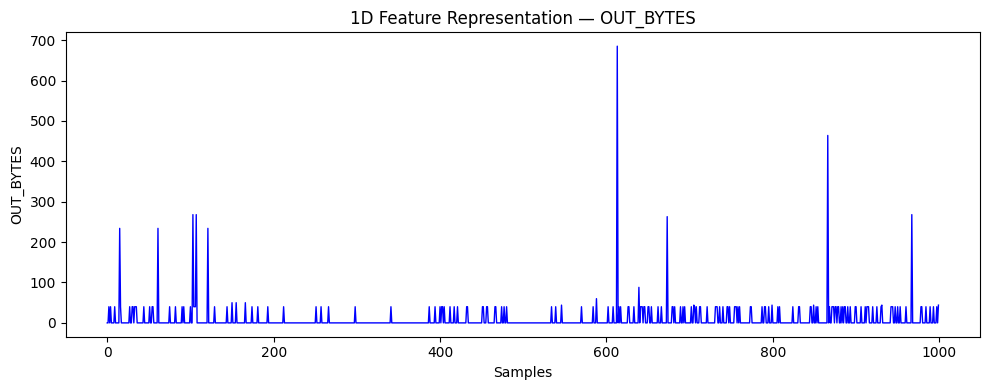

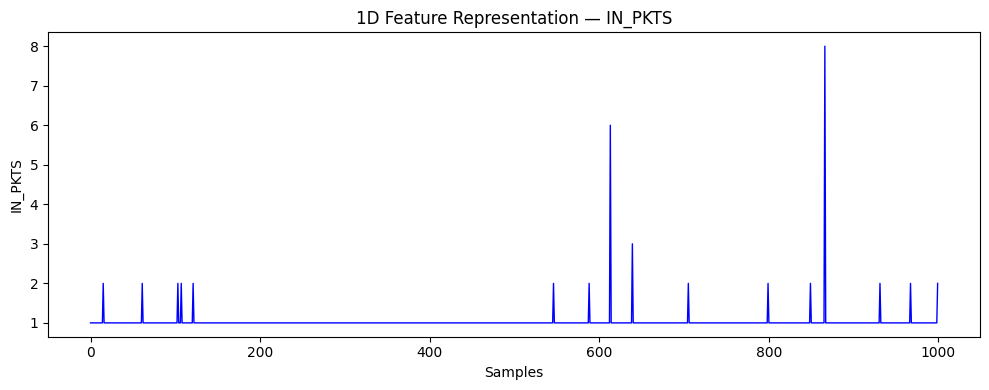

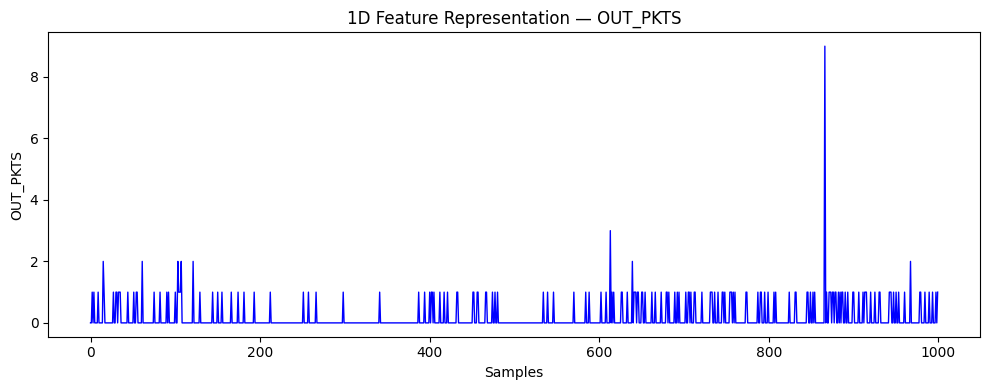

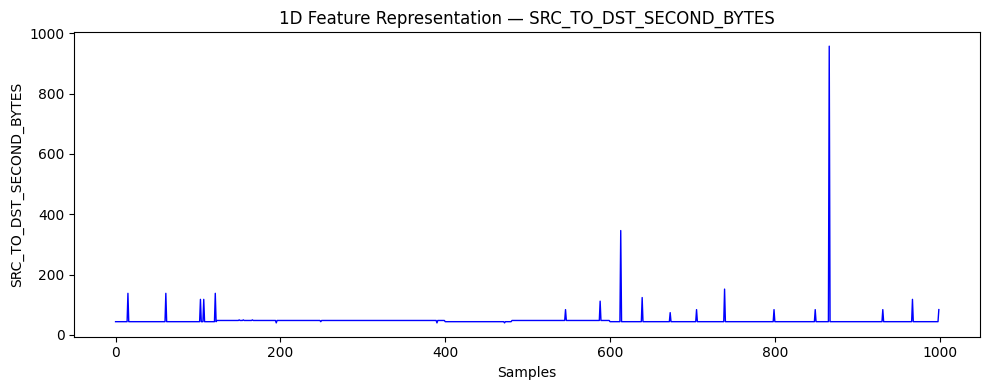

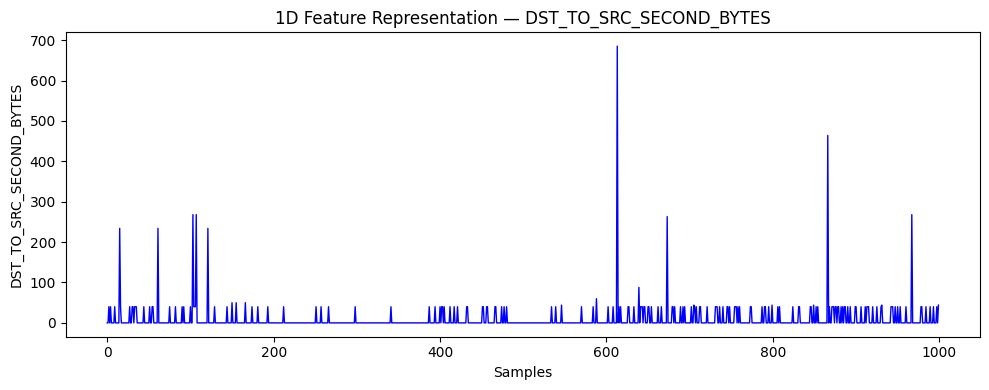

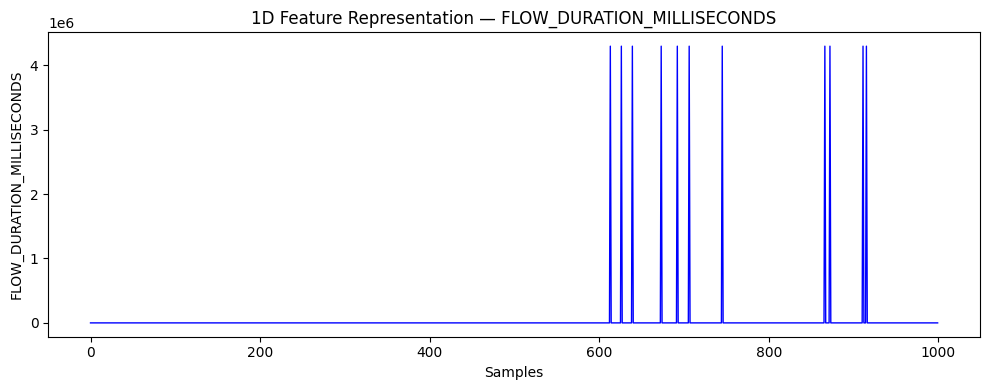

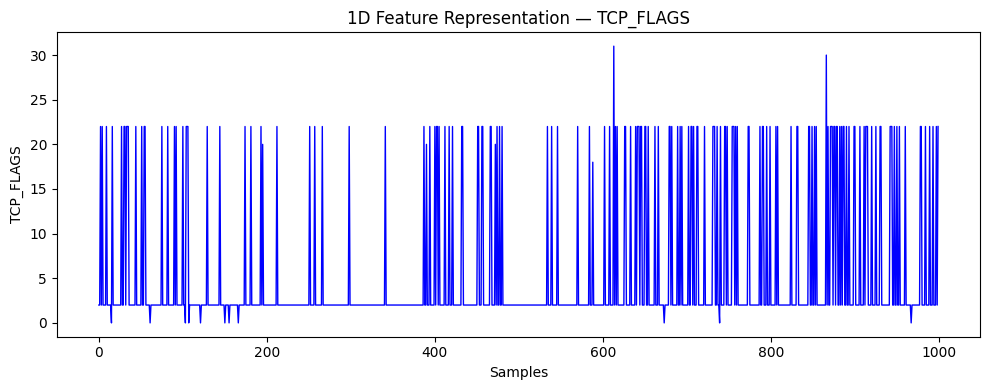

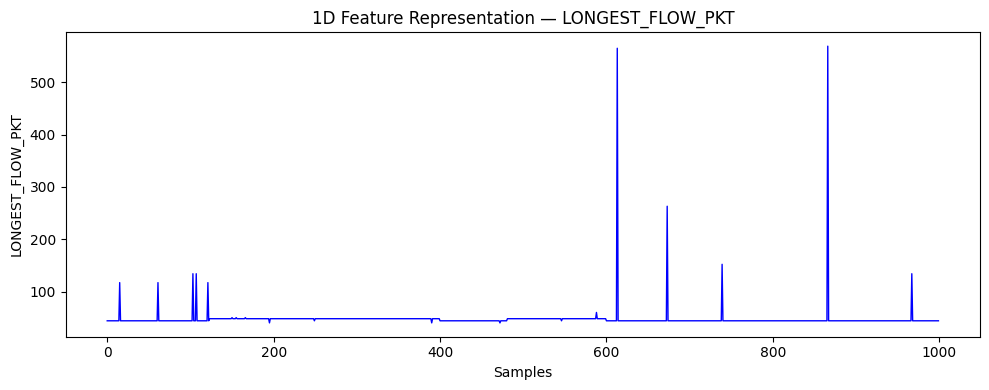

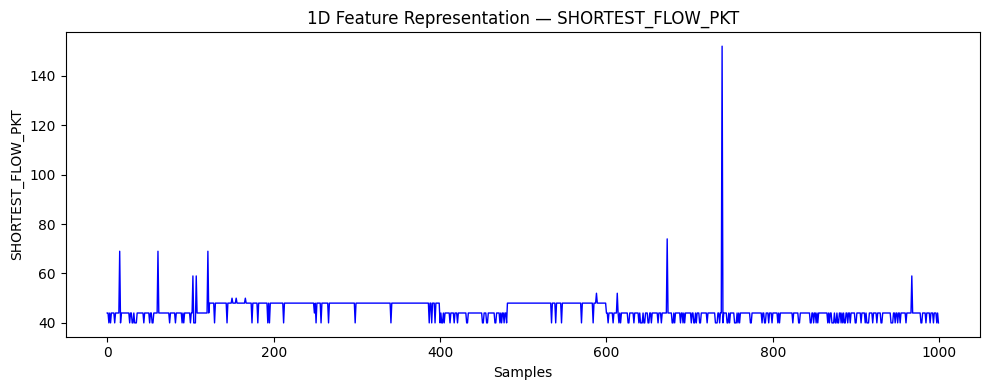

In [13]:
import matplotlib.pyplot as plt

for col in top_features:

    if col not in numeric_df.columns:
        continue

    plt.figure(figsize=(10,4))

    values = numeric_df[col].values[:1000]  # first 1000 samples

    plt.plot(values, color="blue", linewidth=1)

    plt.title(f"1D Feature Representation — {col}")
    plt.xlabel("Samples")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

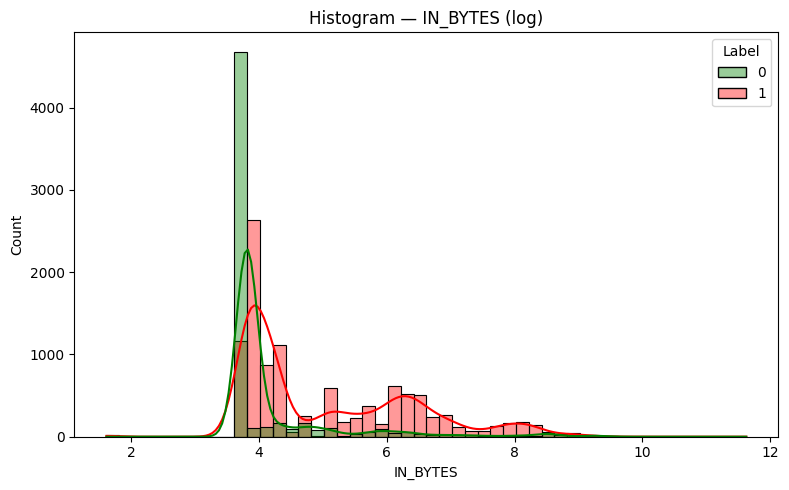

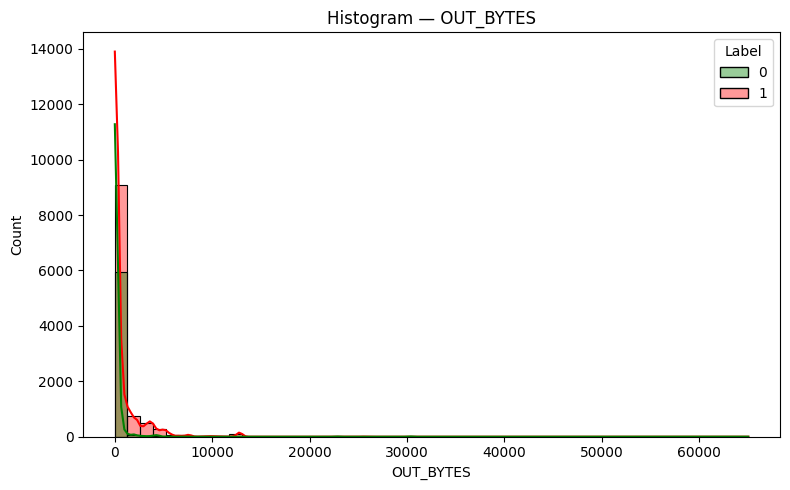

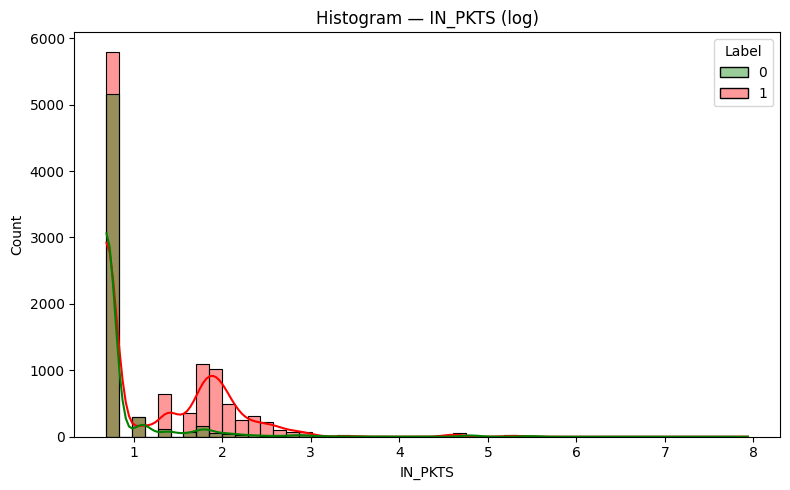

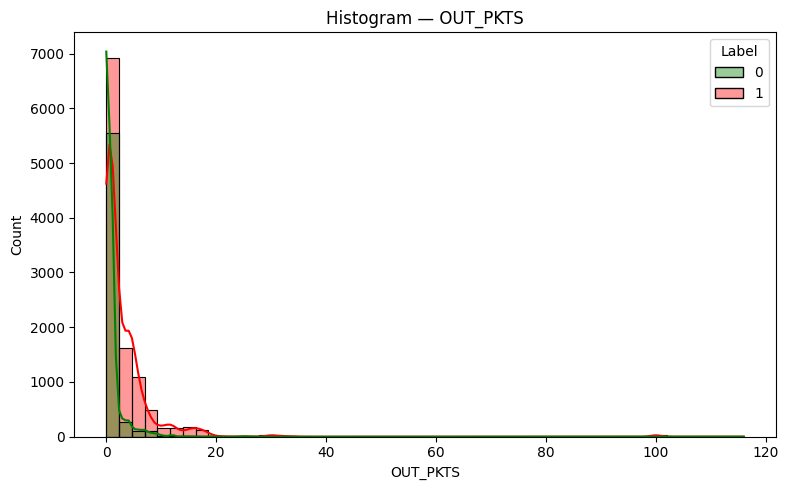

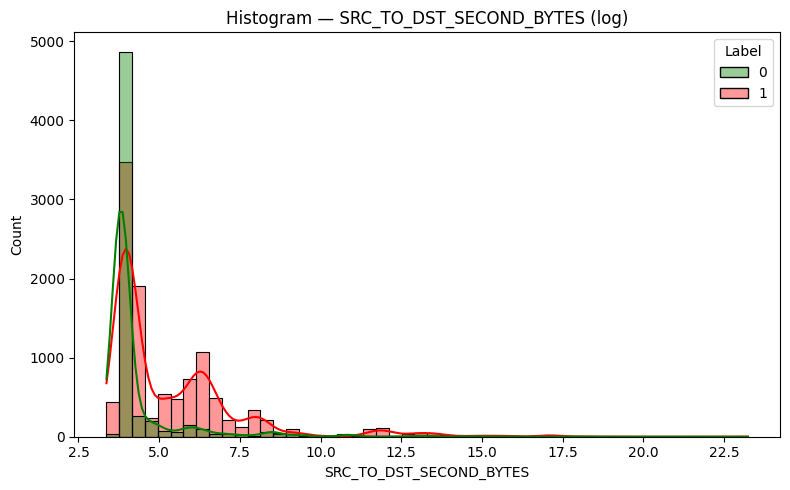

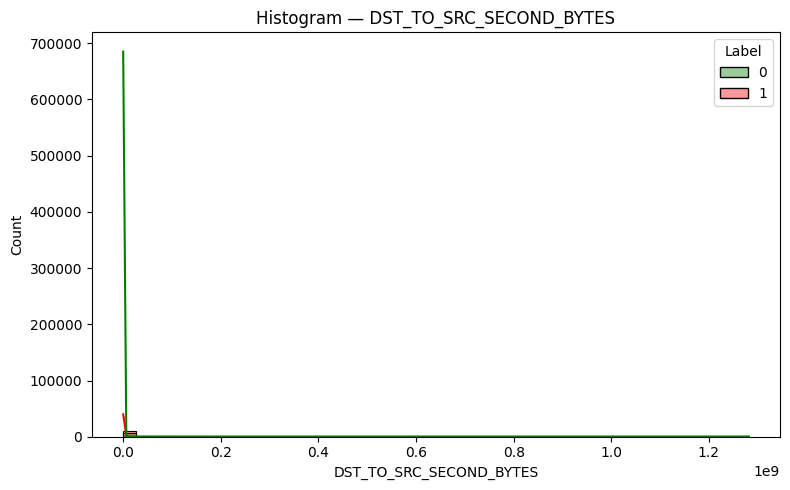

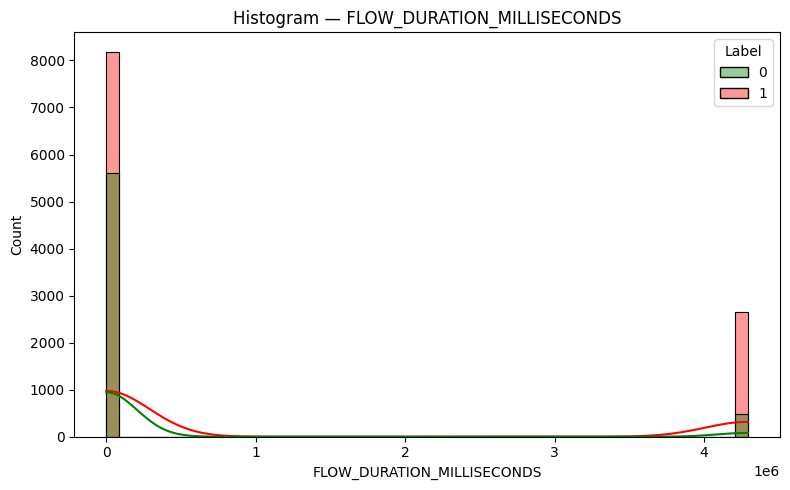

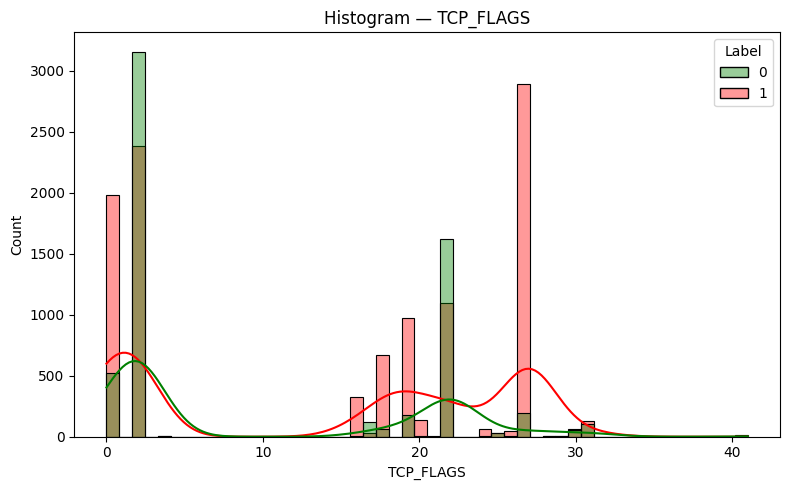

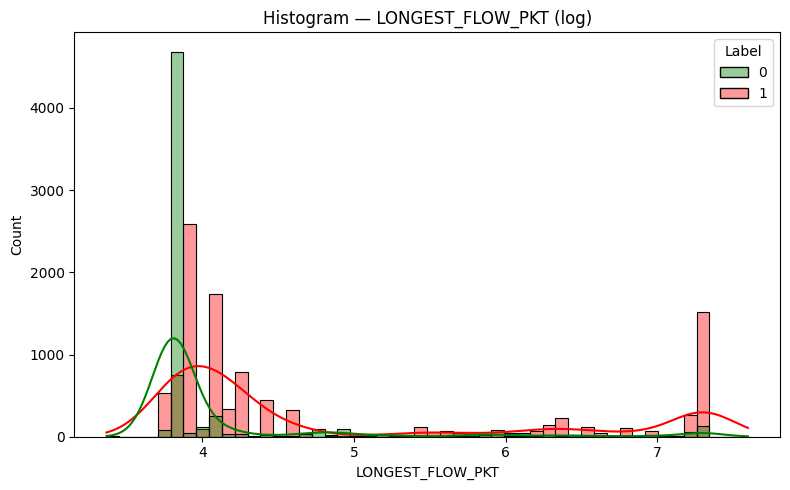

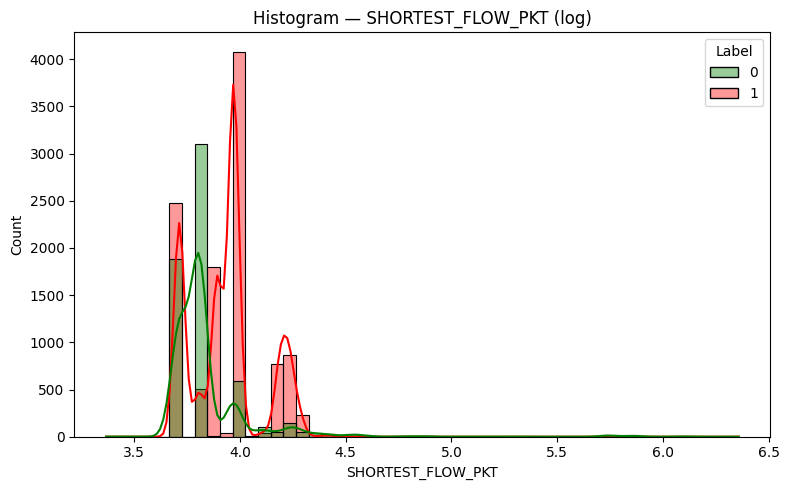

In [14]:
import seaborn as sns

for col in top_features:

    if col not in numeric_df.columns:
        continue

    plt.figure(figsize=(8,5))

    values = numeric_df[col]

    if (values > 0).all():
        values_plot = np.log1p(values)
        title = f"{col} (log)"
    else:
        values_plot = values
        title = col

    sns.histplot(
        x=values_plot,
        hue=df_sample["Label"],
        bins=50,
        kde=True,
        palette=["green", "red"],
        alpha=0.4
    )

    plt.title(f"Histogram — {title}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()


In [15]:
top_features = [
    "IN_BYTES",
    "OUT_BYTES",
    "IN_PKTS",
    "OUT_PKTS",
    "SRC_TO_DST_SECOND_BYTES",
    "DST_TO_SRC_SECOND_BYTES",
    "FLOW_DURATION_MILLISECONDS",
    "TCP_FLAGS",
    "LONGEST_FLOW_PKT",
    "SHORTEST_FLOW_PKT"
]
